

---

# **CE4041 Project 1: Deep-Learning MNIST Digit Classifier**



---




## **Problem Statement:**

Develop a program in Python, (http://www.python.org) using the Keras neural network library (Tensorflow-hosted version), to implement a classifier for the MNIST handwritten digits database.

Your classifier much achieve at least 99% classification accuracy on the MNIST testing set. Investigate the use of a convolutional neural network.

## **Submitted By:**
1. Aakanksha Rawat - 25243829
2. Asghar Aga Murthuza - 25210645
3. Bhagyalakshmy Saburaj - 25275224
4. Rosanne Josephin Fernando - 25275216
5. Roshni Ravi - 25015168

## **Import all the necessasy packages and load the dataset**

In [39]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the data
x_train, x_test = x_train / 255.0, x_test / 255.0

# Print shapes (as you have done)
print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)


Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


### **Visualizing the dataset to inspect the image quality.**

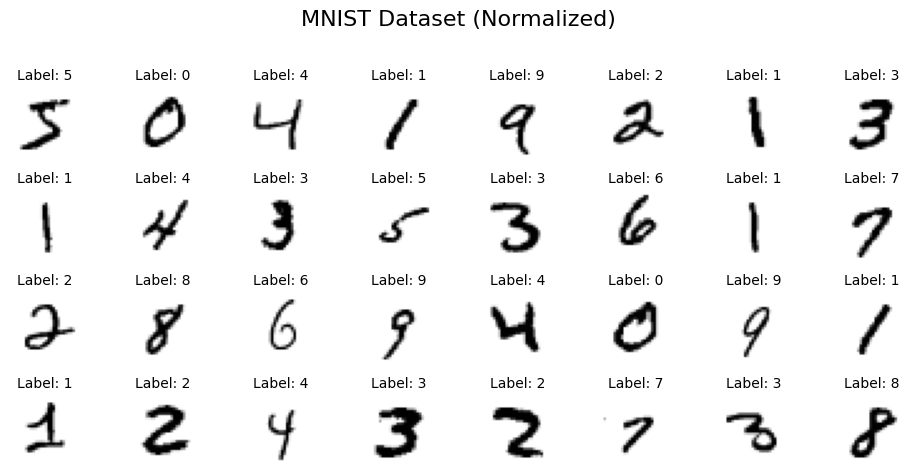

In [40]:
def visualize_mnist(images, labels, num_rows=4, num_cols=8):
    """Displays a grid of MNIST images and their labels."""

    # Calculate total number of images to display
    num_images = num_rows * num_cols

    # Create the figure and subplots
    plt.figure(figsize=(num_cols * 1.2, num_rows * 1.2))
    plt.suptitle("MNIST Dataset (Normalized)", fontsize=16)

    for i in range(num_images):
        plt.subplot(num_rows, num_cols, i + 1)

        # Display the image (using 'binary' colormap for grayscale images)
        plt.imshow(images[i], cmap='binary')

        # Set the title to the corresponding label
        plt.title(f"Label: {labels[i]}", fontsize=10)

        # Remove axis ticks/labels for a cleaner look
        plt.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make space for suptitle
    plt.show()

# Visualize the first 32 images from the training set
visualize_mnist(x_train, y_train)

### **Building a Multi-Layer CNN Model for MNIST Classification**

In [41]:
model = models.Sequential([
    # First Conv/Pool block (Output size: 14x14)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Second Conv/Pool block (Output size: 7x7)
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

### **Model architecture**

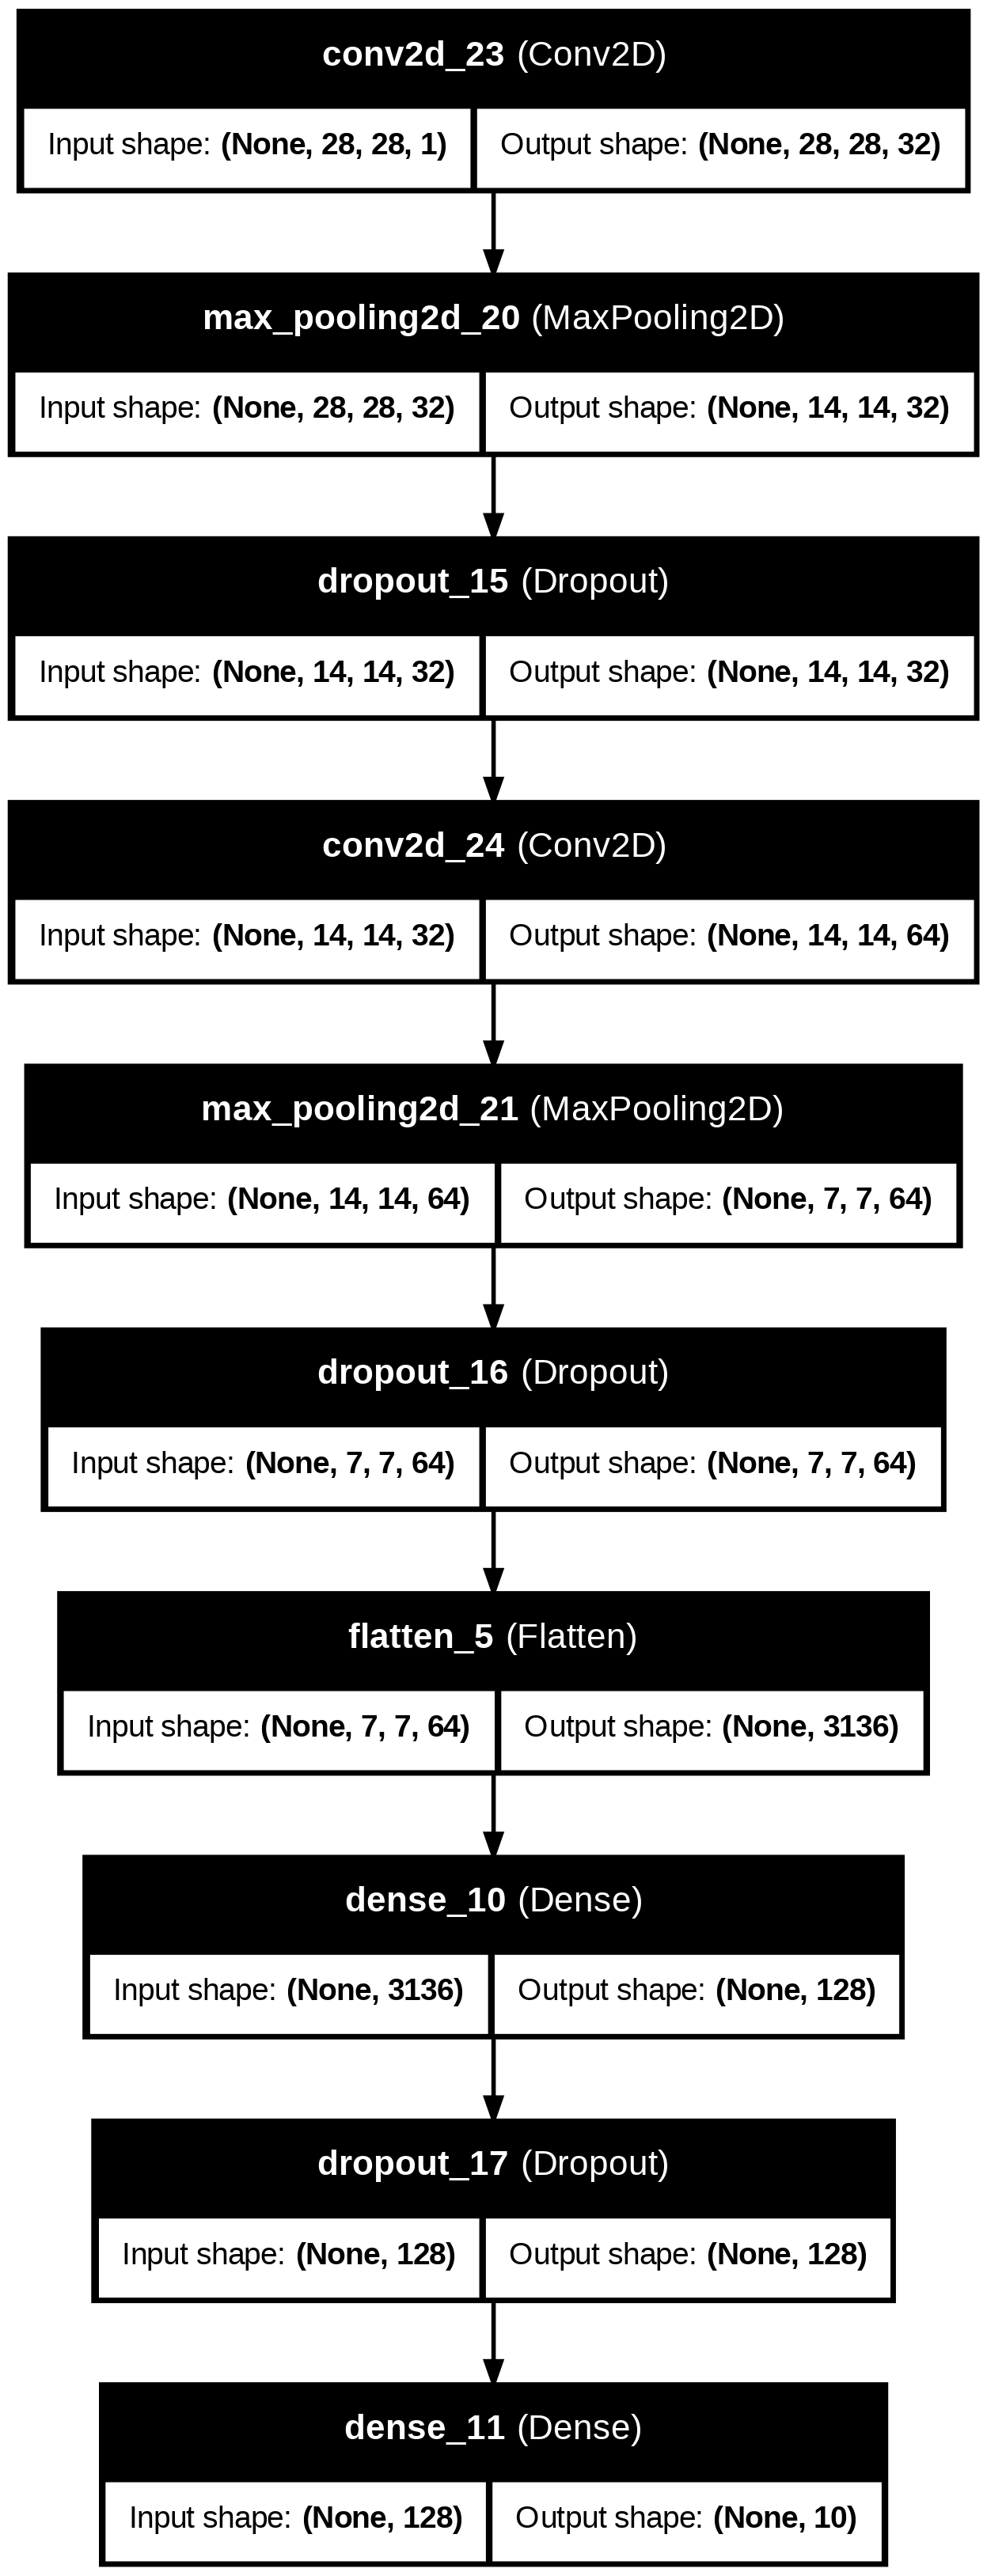

In [43]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True, show_layer_names=True)

In [44]:
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

history = model.fit(x_train, y_train, epochs=50,
                    validation_split=0.2,
                    callbacks=[early_stop],
                    batch_size=64)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("Test accuracy:", test_acc*100)


Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8422 - loss: 0.4711 - val_accuracy: 0.9780 - val_loss: 0.0707
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9764 - loss: 0.0748 - val_accuracy: 0.9864 - val_loss: 0.0469
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9838 - loss: 0.0545 - val_accuracy: 0.9872 - val_loss: 0.0455
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9859 - loss: 0.0428 - val_accuracy: 0.9899 - val_loss: 0.0356
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9889 - loss: 0.0362 - val_accuracy: 0.9899 - val_loss: 0.0369
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9908 - loss: 0.0304 - val_accuracy: 0.9898 - val_loss: 0.0348
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9918 - loss: 0.0273 - val_accuracy: 0.9907 - val_loss: 0.0324
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9917 - loss: 0.0251 - val_accuracy: 0

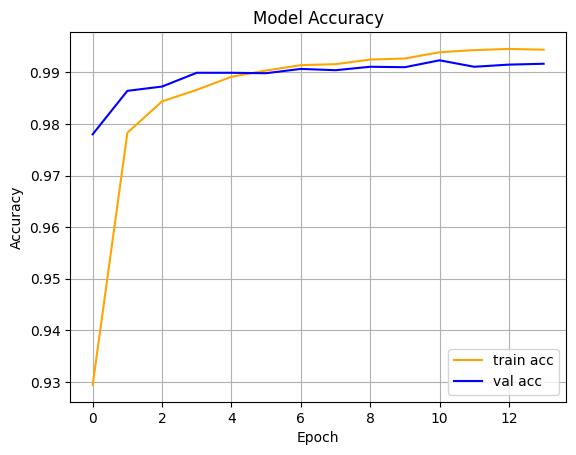

In [45]:
# plot showing accuracy per epoch
plt.plot(history.history['accuracy'], label='train acc',color = 'orange')
plt.plot(history.history['val_accuracy'], label='val acc',color = 'blue')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()



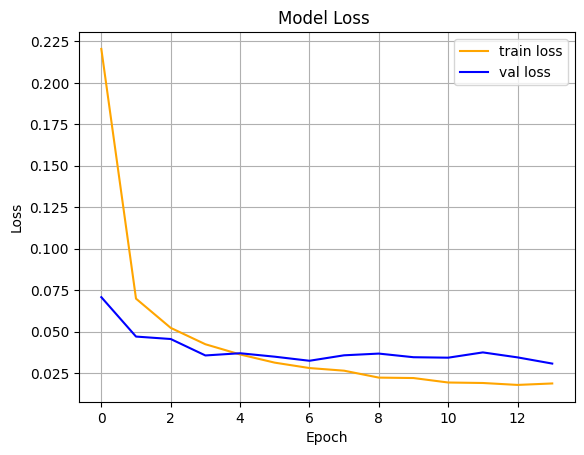

In [46]:
#Plot showing Loss per epoch
plt.plot(history.history['loss'], label='train loss',color='orange')
plt.plot(history.history['val_loss'], label='val loss',color = 'blue')
plt.title('Model Loss ')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### **Confusion matrix**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


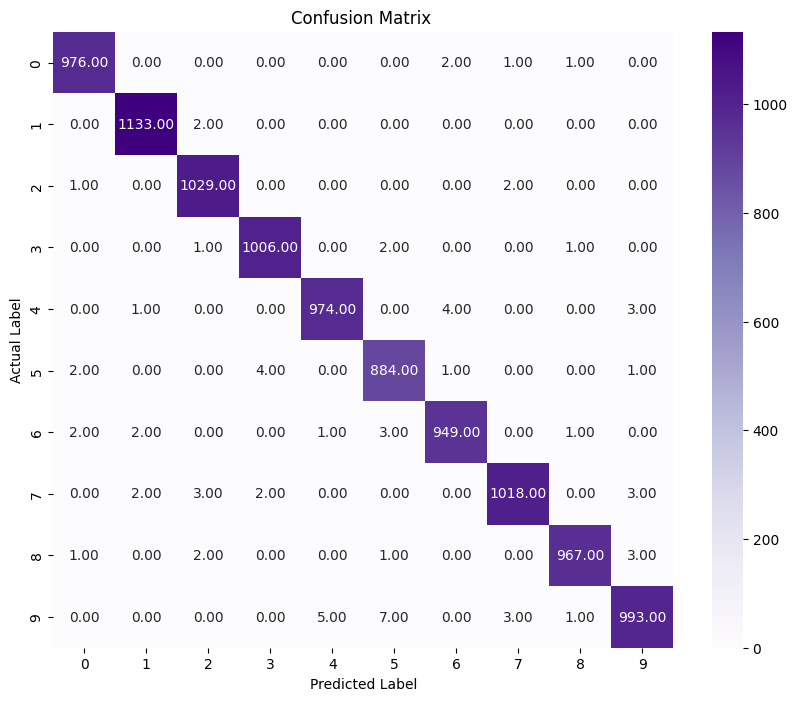

In [47]:
#1. Get the model's predictions on the testing data
y_pred_probs = model.predict(x_test)

# 2. Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Calculate the confusion matrix
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_pred).numpy()

# 4. Convert the matrix to a Pandas DataFrame for Seaborn plotting
class_names = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# 5. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df,
            annot=True,     # Annotate with the numerical values
            cmap='Purples', # Use a color map
            fmt='.2f',      # Format annotations to 2 decimal places
            cbar=True)      # Show color bar

plt.title('Confusion Matrix ')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# **Building a new model for comparing the performances**

In [134]:
model_2 = models.Sequential([
    # First Conv/Pool block (Output size: 14x14)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Second Conv/Pool block (Output size: 7x7)
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3,3), activation='relu'), #adding one more hidden layer

    # Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [135]:
model_2.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_49 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 5, 5, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,962 (1023.29 KB)

 Trainable params: 261,962 (1023.29 KB)

 Non-trainable params: 0 (0.00 B)

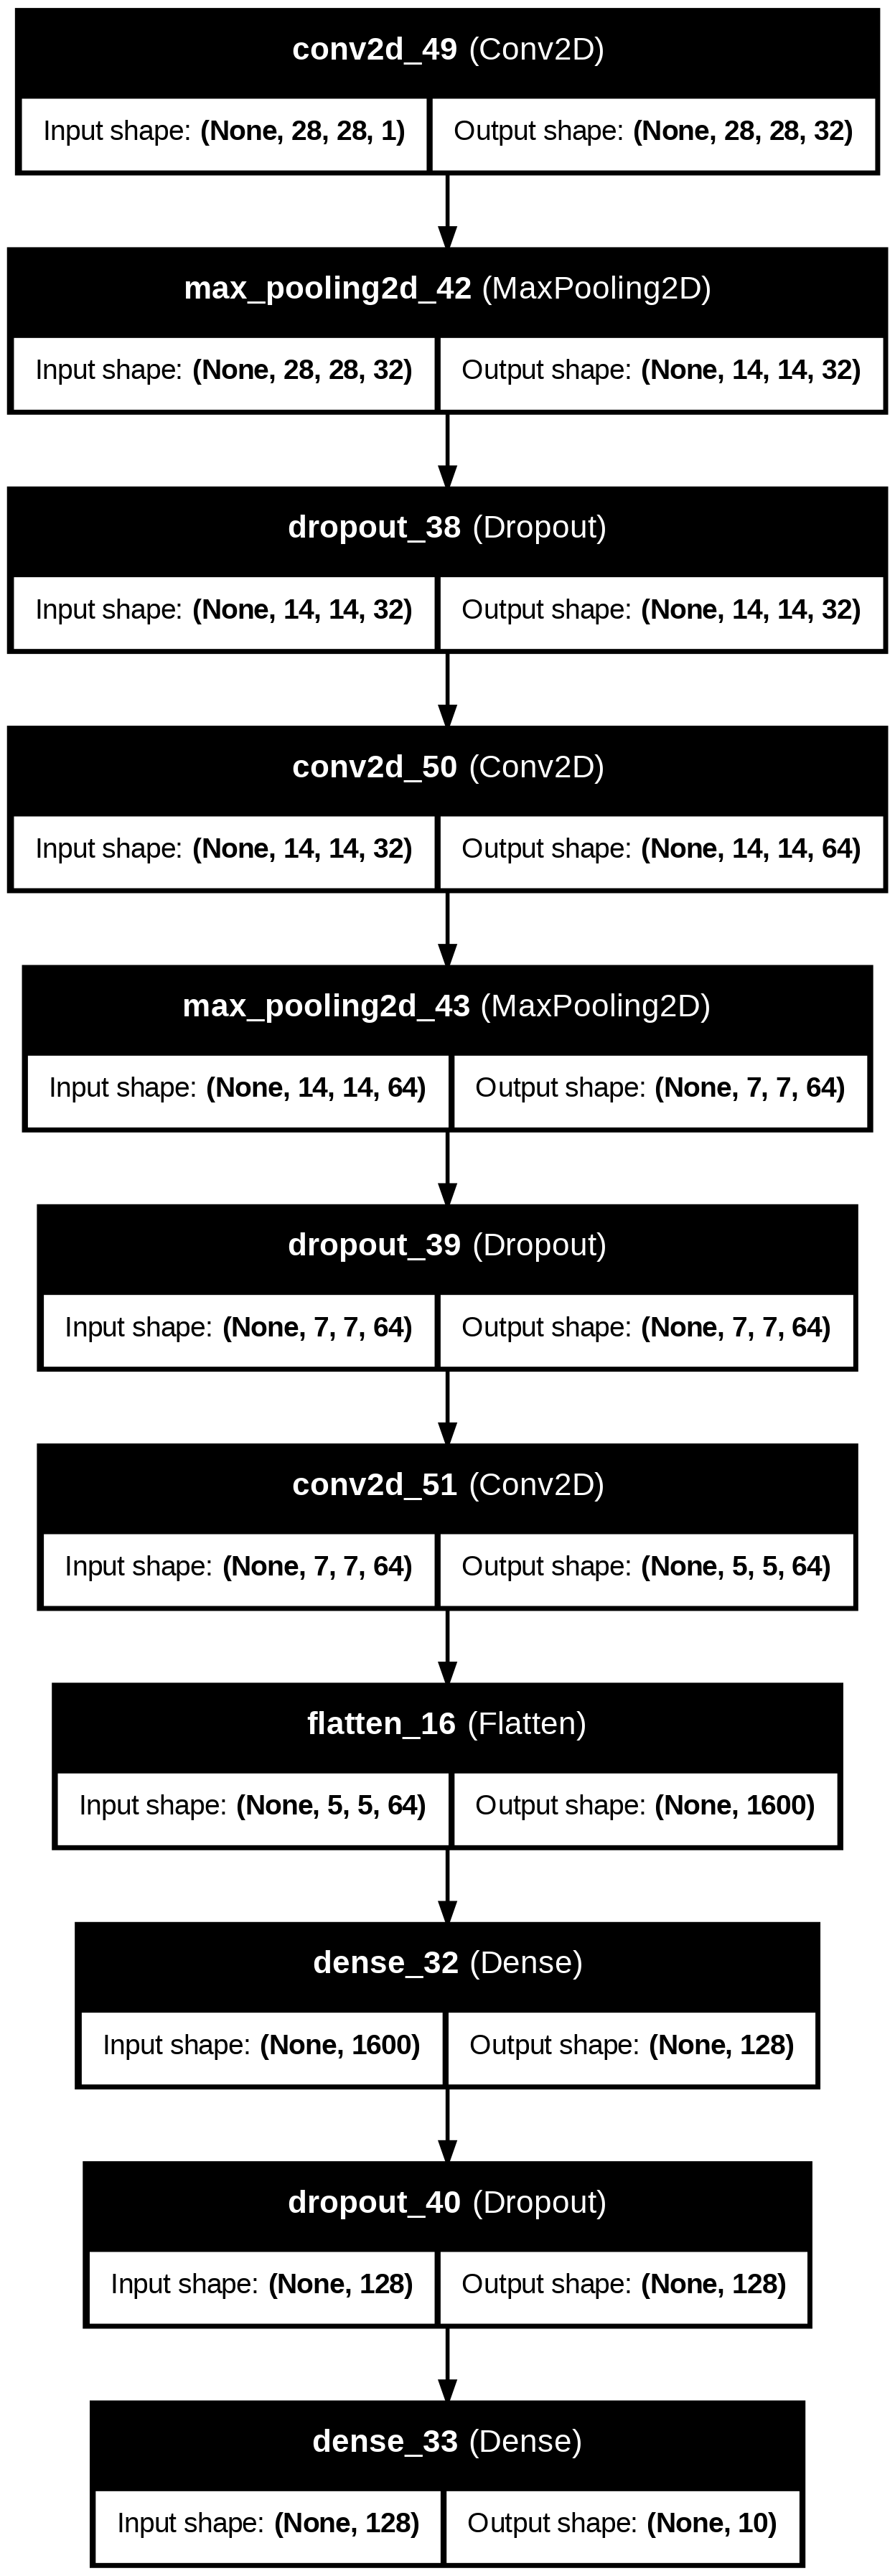

In [136]:
from tensorflow.keras.utils import plot_model
plot_model(model_2, show_shapes=True, show_layer_names=True)

In [137]:
model_2.compile(optimizer='adam', #using adam optimizer instead of rmsprop
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop_2 = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

history_2 = model_2.fit(x_train, y_train, epochs=50,
                    validation_split=0.2,
                    callbacks=[early_stop_2],
                    batch_size=64)
test_loss_2, test_acc_2 = model.evaluate(x_test, y_test, verbose=2)
print("Test accuracy:", test_acc_2*100)


Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8141 - loss: 0.5578 - val_accuracy: 0.9832 - val_loss: 0.0592
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9736 - loss: 0.0866 - val_accuracy: 0.9847 - val_loss: 0.0485
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9813 - loss: 0.0583 - val_accuracy: 0.9883 - val_loss: 0.0400
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9857 - loss: 0.0472 - val_accuracy: 0.9902 - val_loss: 0.0349
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9871 - loss: 0.0401 - val_accuracy: 0.9903 - val_loss: 0.0370
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9898 - loss: 0.0334 - val_accuracy: 0.9917 - val_loss: 0.0306
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9905 - loss: 0.0328 - val_accuracy: 0.9911 - val_loss: 0.0310
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9910 - loss: 0.0289 - val_accuracy: 0.

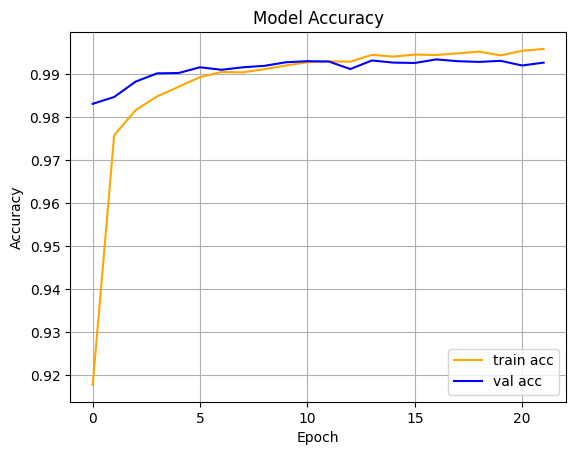

In [138]:
# plot showing accuracy per epoch
plt.plot(history_2.history['accuracy'], label='train acc',color = 'orange')
plt.plot(history_2.history['val_accuracy'], label='val acc',color = 'blue')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


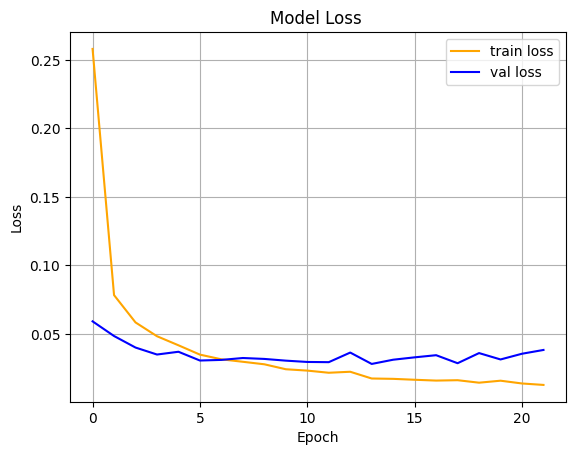

In [139]:
#Plot showing Loss per epoch
plt.plot(history_2.history['loss'], label='train loss',color='orange')
plt.plot(history_2.history['val_loss'], label='val loss',color = 'blue')
plt.title('Model Loss ')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


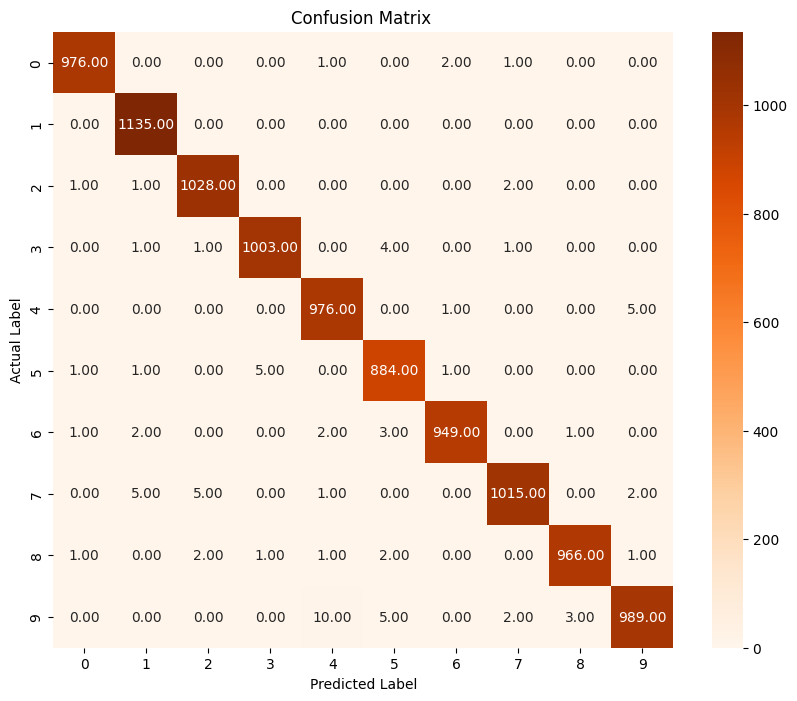

In [140]:
#1. Get the model's predictions on the testing data
y_pred_probs = model_2.predict(x_test)

# 2. Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Calculate the confusion matrix
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_pred).numpy()

# 4. Convert the matrix to a Pandas DataFrame for Seaborn plotting
class_names = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# 5. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df,
            annot=True,     # Annotate with the numerical values
            cmap='Oranges', # Use a color map
            fmt='.2f',      # Format annotations to 2 decimal places
            cbar=True)      # Show color bar

plt.title('Confusion Matrix ')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()